In [ ]:
print('Hello, World!')

# 🏥 AMG-RAG Vietnamese Medical QA System
## Agentic Medical Graph-RAG cho Y tế Tiếng Việt

**Dựa trên:** [AMG-RAG: Agentic Medical Knowledge Graphs Enhance Medical Question Answering](https://arxiv.org/abs/2502.13010)  
**Repo gốc:** [MrRezaeiUofT/AMG-RAG](https://github.com/MrRezaeiUofT/AMG-RAG)  
**Adapted for:** Vietnamese Medical Domain (Vinmec dataset)

---

### 🏗️ Kiến trúc hệ thống (6 components theo paper):
```
Input Query (Tiếng Việt)
       ↓
① Entity Extraction  ──────────────────────────────────────────
       ↓                                                        |
② MKG Construction (NetworkX/Neo4j)   ← Background Update      |
       ↓                               (PubMed + Web Search)   |
③ Hybrid Retrieval (Vector + Graph + Web)                      |
       ↓                                                        |
④ Entity Summarization                                         |
       ↓                                                        |
⑤ Chain-of-Thought Reasoning (LangGraph Agent)                 |
       ↓                                                        |
⑥ Answer Generation (+ Confidence + Citation)  ────────────────
       ↓
Final Answer (Tiếng Việt) + Reasoning + Sources
```

### 📊 Dữ liệu:
- `articles.json` — 2,215 bài viết y tế (Vinmec)
- `diseases.json` — 386 bệnh (nguyên nhân, triệu chứng, điều trị)
- `drugs.json` — 192 thuốc (chỉ định, chống chỉ định, liều dùng)
- `drug_qa_pairs.json` — 546 cặp QA về thuốc

---

## 📦 CELL 1: Cài đặt thư viện

In [ ]:
# ============================================================
# CELL 1: Cài đặt tất cả thư viện cần thiết
# Thời gian: ~3-5 phút lần đầu
# ============================================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

packages = [
    # Core LLM & Agent framework (bám sát repo gốc)
    'langchain>=0.3.0',
    'langchain-community>=0.3.0',
    'langchain-huggingface',
    'langgraph>=0.2.0',

    # LLM backends
    'langchain-ollama',          # Ollama local
    'langchain-openai',          # OpenAI / Groq
    'openai',

    # Vector DB (repo gốc dùng Chroma)
    'chromadb>=0.5.0',
    'langchain-chroma',

    # Embeddings - multilingual cho tiếng Việt
    'sentence-transformers>=3.0.0',

    # Knowledge Graph (repo gốc dùng NetworkX, optional Neo4j)
    'networkx>=3.0',
    'matplotlib',

    # Text processing
    'underthesea',               # NLP tiếng Việt
    'pyvi',                      # Vietnamese tokenizer

    # Data & utils
    'pandas',
    'numpy',
    'tqdm',
    'python-dotenv',
    'rank-bm25',                 # BM25 cho hybrid retrieval
    'requests',
    'wikipedia-api',

    # Evaluation
    'ragas',
    'rouge-score',
    'nltk',
]

for pkg in packages:
    try:
        install(pkg)
        print(f'✅ {pkg}')
    except Exception as e:
        print(f'⚠️  {pkg}: {e}')

print('\n🎉 Cài đặt hoàn tất!')

✅ langchain>=0.3.0
✅ langchain-community>=0.3.0
✅ langchain-huggingface
✅ langgraph>=0.2.0
✅ langchain-ollama
✅ langchain-openai
✅ openai
✅ chromadb>=0.5.0
✅ langchain-chroma
✅ sentence-transformers>=3.0.0
✅ networkx>=3.0
✅ matplotlib
✅ underthesea
✅ pyvi
✅ pandas
✅ numpy
✅ tqdm
✅ python-dotenv
✅ rank-bm25
✅ requests
✅ wikipedia-api
✅ ragas
✅ rouge-score
✅ nltk

🎉 Cài đặt hoàn tất!


## ⚙️ CELL 2: Cấu hình hệ thống

In [ ]:
# ============================================================
# CELL 2: Cấu hình - Chỉnh sửa theo môi trường của bạn
# ============================================================

import os
from dataclasses import dataclass, field
from enum import Enum

class LLMBackend(Enum):
    GROQ = "groq"          # Free, nhanh, Colab tốt
    OPENAI = "openai"      # OpenAI chính thức
    OPENAI_COMPAT = "openai_compat"  # OpenAI-compatible endpoint
    OLLAMA = "ollama"      # Local (cần GPU mạnh)
    GEMINI = "gemini"      # Google AI Studio (có free tier)

@dataclass
class Config:
    # ─── CHỌN LLM BACKEND ───────────────────────────────────
    LLM_BACKEND: LLMBackend = LLMBackend.OPENAI_COMPAT

    # ─── API KEYS (điền key của bạn vào đây) ────────────────
    # Groq: https://console.groq.com (miễn phí, nhanh)
    GROQ_API_KEY: str = ""  # ← ĐIỀN KEY GROQ CỦA BẠN
    # OpenAI compatible: base_url + api_key
    OPENAI_API_KEY: str = "sk-dummy"
    OPENAI_BASE_URL: str = "https://llm.phuocnguyn.id.vn/v1"
    OPENAI_DEFAULT_HEADERS: dict = field(default_factory=lambda: {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json"
    })

    # Google Gemini: https://aistudio.google.com
    GOOGLE_API_KEY: str = ""  # ← ĐIỀN KEY GEMINI (nếu dùng)

    # ─── MODEL SETTINGS ─────────────────────────────────────
    GROQ_MODEL: str = "llama-3.3-70b-versatile"
    OPENAI_MODEL: str = "google/gemma-3-27b-it-qat-q4_0-gguf:Q4_0"
    OLLAMA_MODEL: str = "qwen2.5:14b"
    GEMINI_MODEL: str = "gemini-1.5-flash"

    # ─── EMBEDDING MODEL (Multilingual cho Tiếng Việt) ──────
    EMBEDDING_MODEL: str = "BAAI/bge-m3"
    # EMBEDDING_MODEL = "intfloat/multilingual-e5-large"  # Alternative

    # ─── KNOWLEDGE GRAPH SETTINGS (theo paper) ──────────────
    MAX_ENTITIES: int = 8          # Số entities tối đa mỗi query
    CONFIDENCE_THRESHOLD: float = 0.7  # Ngưỡng confidence (paper dùng 0.8)
    MAX_GRAPH_DEPTH: int = 3       # Độ sâu duyệt graph
    MAX_ITERATIONS: int = 5        # Số vòng lặp agent tối đa

    # ─── RETRIEVAL SETTINGS ──────────────────────────────────
    TOP_K_VECTOR: int = 5          # Số documents từ vector search
    TOP_K_BM25: int = 3            # Số documents từ BM25
    TOP_K_GRAPH: int = 5           # Số nodes từ graph traversal
    CHUNK_SIZE: int = 512          # Kích thước chunk (theo paper: 512)
    CHUNK_OVERLAP: int = 100       # Overlap (theo paper: 100)

    # ─── PATHS (local) ───────────────────────────────────────
    DATA_DIR: str = "D:/Final_Project/Final_Project/CrawlVinmec/vinmec_complete_data"
    CHROMA_DIR: str = "D:/Final_Project/Final_Project/artifacts/chroma_db"
    GRAPH_DIR: str = "D:/Final_Project/Final_Project/artifacts/graphs"
    RESULTS_DIR: str = "D:/Final_Project/Final_Project/artifacts/results"

    # ─── COLAB OPTIMIZATION ──────────────────────────────────
    BATCH_SIZE: int = 100          # Batch size khi ingest (tránh OOM)
    USE_GPU_EMBEDDING: bool = True # Dùng GPU cho embedding nếu có
    MAX_DOCS_DEMO: int = 500       # Giới hạn docs cho demo nhanh

config = Config()

# Tạo thư mục
for d in [config.CHROMA_DIR, config.GRAPH_DIR, config.RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Set API keys vào environment
if config.GROQ_API_KEY:
    os.environ['GROQ_API_KEY'] = config.GROQ_API_KEY
if config.OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = config.OPENAI_API_KEY
if config.GOOGLE_API_KEY:
    os.environ['GOOGLE_API_KEY'] = config.GOOGLE_API_KEY

# Kiểm tra GPU
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'   Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    # CPU fallback: giảm tải để tránh chạy quá lâu
    config.USE_GPU_EMBEDDING = False
    config.MAX_DOCS_DEMO = min(config.MAX_DOCS_DEMO, 200)
    config.BATCH_SIZE = min(config.BATCH_SIZE, 32)
    if config.EMBEDDING_MODEL == "BAAI/bge-m3":
        config.EMBEDDING_MODEL = "intfloat/multilingual-e5-small"
    print('   CPU mode: giảm MAX_DOCS_DEMO/BATCH_SIZE và dùng embedding nhỏ hơn')

print('✅ Config đã sẵn sàng!')
print(f'   LLM Backend: {config.LLM_BACKEND.value}')
print(f'   Embedding: {config.EMBEDDING_MODEL}')
print(f'   Confidence threshold: {config.CONFIDENCE_THRESHOLD}')
print(f'   Chunk size: {config.CHUNK_SIZE} (overlap: {config.CHUNK_OVERLAP})')
print(f'   Data dir: {config.DATA_DIR}')

   Device: cpu
   CPU mode: giảm MAX_DOCS_DEMO/BATCH_SIZE và dùng embedding nhỏ hơn
✅ Config đã sẵn sàng!
   LLM Backend: openai_compat
   Embedding: intfloat/multilingual-e5-small
   Confidence threshold: 0.7
   Chunk size: 512 (overlap: 100)
   Data dir: D:/Final_Project/Final_Project/CrawlVinmec/vinmec_complete_data


## 📂 CELL 3: Upload và xử lý dữ liệu

In [ ]:
# ============================================================
# CELL 3: Load dữ liệu từ local (không dùng Colab upload)
# ============================================================

import json
import os
from tqdm import tqdm

required_files = [
    "articles.json",
    "diseases.json",
    "drugs.json",
    "drug_qa_pairs.json",
]

print('📁 Kiểm tra 4 file JSON đầu vào:')
missing = []
for fname in required_files:
    fpath = os.path.join(config.DATA_DIR, fname)
    if not os.path.exists(fpath):
        missing.append(fname)
        print(f'   ❌ Thiếu: {fname}')
    else:
        print(f'   ✅ Có: {fname}')

if missing:
    raise FileNotFoundError(f'Missing files in {config.DATA_DIR}: {missing}')

# ─── Load và kiểm tra dữ liệu ────────────────────────────────
def load_json(filename):
    path = os.path.join(config.DATA_DIR, filename)
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

articles = load_json('articles.json')
diseases = load_json('diseases.json')
drugs = load_json('drugs.json')
drug_qa = load_json('drug_qa_pairs.json')

print(f'\n📊 Thống kê dữ liệu:')
print(f'   Articles: {len(articles):,} bài viết')
print(f'   Diseases: {len(diseases):,} bệnh')
print(f'   Drugs:    {len(drugs):,} thuốc')
print(f'   Drug QA:  {len(drug_qa):,} cặp QA')
print(f'   Total:    {len(articles)+len(diseases)+len(drugs):,} documents')

📁 Kiểm tra 4 file JSON đầu vào:
   ✅ Có: articles.json
   ✅ Có: diseases.json
   ✅ Có: drugs.json
   ✅ Có: drug_qa_pairs.json

📊 Thống kê dữ liệu:
   Articles: 2,215 bài viết
   Diseases: 386 bệnh
   Drugs:    192 thuốc
   Drug QA:  546 cặp QA
   Total:    2,793 documents


## 🔧 CELL 4: Vietnamese Text Preprocessor

In [ ]:
# ============================================================
# CELL 4: Vietnamese Text Preprocessor
# Xử lý văn bản tiếng Việt đặc thù
# ============================================================

import re
from typing import List, Dict, Optional

class VietnameseMedicalPreprocessor:
    """
    Preprocessor chuyên biệt cho văn bản y tế tiếng Việt.
    Xử lý các đặc thù: dấu thanh, thuật ngữ y tế, viết tắt.
    """

    # Từ điển viết tắt y tế tiếng Việt thường gặp
    MEDICAL_ABBREVIATIONS = {
        'HA': 'huyết áp',
        'ĐTĐ': 'đái tháo đường',
        'THA': 'tăng huyết áp',
        'BMI': 'chỉ số khối cơ thể',
        'ECG': 'điện tâm đồ',
        'MRI': 'chụp cộng hưởng từ',
        'CT': 'chụp cắt lớp vi tính',
        'BN': 'bệnh nhân',
        'BS': 'bác sĩ',
        'THCS': 'trung học cơ sở',
        'WHO': 'Tổ chức Y tế Thế giới',
        'BYT': 'Bộ Y tế',
        'NSAID': 'thuốc kháng viêm không steroid',
        'ACE': 'men chuyển angiotensin',
    }

    def __init__(self):
        self.sentence_pattern = re.compile(
            r'(?<=[.!?])\s+(?=[A-ZÀ-Ỵ])', re.UNICODE
        )

    def clean_text(self, text: str) -> str:
        """Làm sạch văn bản tiếng Việt"""
        if not text or not isinstance(text, str):
            return ""
        # Xóa HTML tags
        text = re.sub(r'<[^>]+>', ' ', text)
        # Chuẩn hóa khoảng trắng
        text = re.sub(r'\s+', ' ', text)
        # Xóa ký tự đặc biệt không cần thiết
        text = re.sub(r'[\x00-\x08\x0b-\x1f\x7f]', '', text)
        # Xóa dòng trống thừa
        text = re.sub(r'\n{3,}', '\n\n', text)
        return text.strip()

    def extract_text_from_article(self, article: dict) -> str:
        """Trích xuất văn bản đầy đủ từ article JSON"""
        parts = []
        if article.get('tieu_de'):
            parts.append(f"Tiêu đề: {article['tieu_de']}")
        if article.get('mo_ta'):
            parts.append(f"Mô tả: {article['mo_ta']}")
        if article.get('noi_dung'):
            parts.append(article['noi_dung'])
        elif article.get('phan_doan'):
            for section in article['phan_doan']:
                if section.get('title'):
                    parts.append(f"## {section['title']}")
                if section.get('content'):
                    if isinstance(section['content'], list):
                        parts.extend(section['content'])
                    else:
                        parts.append(str(section['content']))
        return self.clean_text('\n'.join(parts))

    def extract_text_from_disease(self, disease: dict) -> str:
        """Trích xuất văn bản đầy đủ từ disease JSON"""
        parts = []
        # Lấy tên bệnh từ URL
        url = disease.get('url', '')
        name_match = re.search(r'/benh/([^/]+)$', url)
        if name_match:
            name = name_match.group(1).replace('-', ' ')
            parts.append(f"Bệnh: {name}")

        field_labels = {
            'nguyen_nhan': 'Nguyên nhân',
            'yeu_to_nguy_co': 'Yếu tố nguy cơ',
            'trieu_chung': 'Triệu chứng',
            'chan_doan': 'Chẩn đoán',
            'dieu_tri': 'Điều trị',
            'phong_ngua': 'Phòng ngừa',
        }
        for field, label in field_labels.items():
            val = disease.get(field)
            if val and isinstance(val, str) and len(val.strip()) > 10:
                parts.append(f"{label}: {val}")

        if disease.get('noi_dung_day_du'):
            parts.append(disease['noi_dung_day_du'])

        topics = disease.get('chu_de', [])
        if topics:
            parts.append(f"Chủ đề: {', '.join(topics) if isinstance(topics, list) else topics}")

        return self.clean_text('\n'.join(parts))

    def extract_text_from_drug(self, drug: dict) -> str:
        """Trích xuất văn bản đầy đủ từ drug JSON"""
        parts = []
        if drug.get('name'):
            parts.append(f"Thuốc: {drug['name']}")
        if drug.get('formulation'):
            parts.append(f"Dạng bào chế: {drug['formulation']}")
        if drug.get('drug_group'):
            parts.append(f"Nhóm thuốc / Tác dụng phụ: {drug['drug_group']}")

        field_labels = {
            'indication': 'Chỉ định',
            'contraindication': 'Chống chỉ định',
            'precaution': 'Thận trọng',
            'side_effects': 'Tác dụng phụ',
            'dosage': 'Liều dùng',
            'usage_notes': 'Lưu ý sử dụng',
        }
        for field, label in field_labels.items():
            val = drug.get(field)
            if val and isinstance(val, str) and len(val.strip()) > 5:
                parts.append(f"{label}: {val}")

        if drug.get('full_text'):
            parts.append(drug['full_text'])

        return self.clean_text('\n'.join(parts))

    def chunk_text(self, text: str, chunk_size: int = 512,
                   overlap: int = 100) -> List[str]:
        """
        Chia văn bản thành chunks theo số từ.
        Bám sát paper: chunk_size=512 tokens, overlap=100.
        """
        if not text:
            return []
        # Tách câu theo dấu câu để giữ ngữ nghĩa
        sentences = re.split(r'(?<=[.!?\n])\s+', text)
        sentences = [s.strip() for s in sentences if s.strip()]

        chunks = []
        current_chunk = []
        current_len = 0

        for sentence in sentences:
            words = sentence.split()
            sent_len = len(words)

            if current_len + sent_len > chunk_size and current_chunk:
                chunks.append(' '.join(current_chunk))
                # Overlap: giữ lại phần cuối
                overlap_words = ' '.join(current_chunk).split()[-overlap:]
                current_chunk = overlap_words
                current_len = len(overlap_words)

            current_chunk.extend(words)
            current_len += sent_len

        if current_chunk:
            chunks.append(' '.join(current_chunk))

        return [c for c in chunks if len(c.strip()) > 50]

# Test preprocessor
preprocessor = VietnameseMedicalPreprocessor()
print('✅ Vietnamese Medical Preprocessor đã sẵn sàng!')
print('\nTest với disease sample:')
sample_text = preprocessor.extract_text_from_disease(diseases[0])
print(f'  Độ dài: {len(sample_text)} chars')
chunks = preprocessor.chunk_text(sample_text)
print(f'  Số chunks: {len(chunks)}')
print(f'  Chunk đầu tiên (100 chars): {chunks[0][:100]}...')

✅ Vietnamese Medical Preprocessor đã sẵn sàng!

Test với disease sample:
  Độ dài: 21529 chars
  Số chunks: 12
  Chunk đầu tiên (100 chars): Bệnh: u te bao khong lo 4453 Nguyên nhân: Nguyên nhân gây bệnh u tế bào khổng lồ hiện nay vẫn còn nh...


## 🔢 CELL 5: Build Vector Database (Chroma)

In [ ]:
# ============================================================
# CELL 5: Build Vector Database
# Sử dụng Chroma (bám sát repo gốc) + BGE-M3 embedding
# Theo paper: all-mpnet-base-v2, nhưng BGE-M3 tốt hơn cho VN
# ============================================================

import torch
from sentence_transformers import SentenceTransformer
from langchain_chroma import Chroma
from langchain.embeddings.base import Embeddings
from langchain_core.documents import Document
from tqdm import tqdm
import numpy as np
import time

# ─── Custom Embedding Wrapper cho SentenceTransformer ────────
class BGEEmbeddings(Embeddings):
    """
    Wrapper cho SentenceTransformer embedding.
    """
    def __init__(self, model_name: str, device: str = 'cpu',
                 batch_size: int = 32):
        print(f'⏳ Đang load embedding model: {model_name}...')
        self.model = SentenceTransformer(model_name, device=device)
        self.batch_size = batch_size
        self.device = device
        print(f'✅ Embedding model loaded! Dimension: {self.model.get_sentence_embedding_dimension()}')

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        embeddings = []
        for i in range(0, len(texts), self.batch_size):
            batch = texts[i:i+self.batch_size]
            batch_emb = self.model.encode(
                batch,
                normalize_embeddings=True,
                show_progress_bar=False
)
            embeddings.extend(batch_emb.tolist())
        return embeddings

    def embed_query(self, text: str) -> List[float]:
        emb = self.model.encode(
            text, normalize_embeddings=True
)
        return emb.tolist()

# ─── Load embedding model ────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() and config.USE_GPU_EMBEDDING else 'cpu'
embeddings = BGEEmbeddings(
    model_name=config.EMBEDDING_MODEL,
    device=device,
    batch_size=64 if device == 'cuda' else 32
)
embedding_dim = embeddings.model.get_sentence_embedding_dimension()
collection_name = f'vietnamese_medical_{embedding_dim}d'

# ─── Chuẩn bị documents ─────────────────────────────────────
print('\n⏳ Đang chuẩn bị documents...')
all_documents = []

# Process Articles
print('  📄 Processing articles...')
for i, article in enumerate(tqdm(articles[:config.MAX_DOCS_DEMO], desc='Articles')):
    text = preprocessor.extract_text_from_article(article)
    if len(text) < 100:
        continue
    chunks = preprocessor.chunk_text(text, config.CHUNK_SIZE, config.CHUNK_OVERLAP)
    topics = article.get('chu_de', [])
    for j, chunk in enumerate(chunks):
        all_documents.append(Document(
            page_content=chunk,
            metadata={
                'source': article.get('url', f'article_{i}'),
                'title': article.get('tieu_de', ''),
                'type': 'article',
                'topics': ', '.join(topics) if isinstance(topics, list) else str(topics),
                'chunk_id': j,
                'doc_id': f'article_{i}'
            }
        ))

# Process Diseases
print('  🏥 Processing diseases...')
for i, disease in enumerate(tqdm(diseases, desc='Diseases')):
    text = preprocessor.extract_text_from_disease(disease)
    if len(text) < 100:
        continue
    chunks = preprocessor.chunk_text(text, config.CHUNK_SIZE, config.CHUNK_OVERLAP)
    topics = disease.get('chu_de', [])
    for j, chunk in enumerate(chunks):
        all_documents.append(Document(
            page_content=chunk,
            metadata={
                'source': disease.get('url', f'disease_{i}'),
                'type': 'disease',
                'topics': ', '.join(topics) if isinstance(topics, list) else str(topics),
                'chunk_id': j,
                'doc_id': f'disease_{i}'
            }
        ))

# Process Drugs
print('  💊 Processing drugs...')
for i, drug in enumerate(tqdm(drugs, desc='Drugs')):
    text = preprocessor.extract_text_from_drug(drug)
    if len(text) < 50:
        continue
    chunks = preprocessor.chunk_text(text, config.CHUNK_SIZE, config.CHUNK_OVERLAP)
    for j, chunk in enumerate(chunks):
        all_documents.append(Document(
            page_content=chunk,
            metadata={
                'source': drug.get('url', f'drug_{i}'),
                'name': drug.get('name', ''),
                'type': 'drug',
                'chunk_id': j,
                'doc_id': f'drug_{i}'
            }
        ))

print(f'\n📊 Tổng số chunks: {len(all_documents):,}')

# ─── Build Chroma Vector DB ──────────────────────────────────
print('\n⏳ Đang build Chroma vector database...')
print('   (Quá trình này mất 5-15 phút tùy GPU/CPU và số documents)')

BATCH_BUILD = config.BATCH_SIZE
vectordb = None

start_time = time.time()
for i in tqdm(range(0, len(all_documents), BATCH_BUILD), desc='Building VDB'):
    batch = all_documents[i:i+BATCH_BUILD]
    if vectordb is None:
        vectordb = Chroma.from_documents(
            documents=batch,
            embedding=embeddings,
            persist_directory=config.CHROMA_DIR,
            collection_name=collection_name
)
    else:
        vectordb.add_documents(batch)

elapsed = time.time() - start_time
print(f'\n✅ Vector DB đã xây dựng xong!')
print(f'   Số documents: {vectordb._collection.count():,}')
print(f'   Thời gian: {elapsed:.1f}s')
print(f'   Lưu tại: {config.CHROMA_DIR}')

⏳ Đang load embedding model: intfloat/multilingual-e5-small...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9868.02it/s]
C:\Users\Admin\AppData\Local\Temp\ipykernel_20356\4226102880.py:27: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'✅ Embedding model loaded! Dimension: {self.model.get_sentence_embedding_dimension()}')
C:\Users\Admin\AppData\Local\Temp\ipykernel_20356\4226102880.py:54: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = embeddings.model.get_sentence_embedding_dimension()


✅ Embedding model loaded! Dimension: 384

⏳ Đang chuẩn bị documents...
  📄 Processing articles...


Articles: 100%|██████████| 200/200 [00:00<00:00, 1096.67it/s]


  🏥 Processing diseases...


...

  💊 Processing drugs...


Drugs: 100%|██████████| 192/192 [00:00<00:00, 3642.82it/s]



📊 Tổng số chunks: 6,399

⏳ Đang build Chroma vector database...
   (Quá trình này mất 5-15 phút tùy GPU/CPU và số documents)


Building VDB: 100%|██████████| 200/200 [13:03<00:00,  3.92s/it]


✅ Vector DB đã xây dựng xong!
   Số documents: 6,399
   Thời gian: 783.3s
   Lưu tại: D:/Final_Project/Final_Project/artifacts/chroma_db


## 🔍 CELL 6: BM25 Retriever (Hybrid Search)

In [ ]:
# ============================================================
# CELL 6: BM25 Retriever cho Hybrid Search
# Kết hợp Vector + BM25 = Hybrid RAG (baseline của bạn)
# ============================================================

from rank_bm25 import BM25Okapi
import pickle

class VietnameseBM25Retriever:
    """
    BM25 retriever với tokenization tiếng Việt.
    Kết hợp với Vector search để tạo Hybrid Retriever.
    """
    def __init__(self, documents: List[Document]):
        self.documents = documents
        print('⏳ Đang build BM25 index...')
        # Vietnamese tokenization: tách theo syllable/word
        tokenized_corpus = [
            self._tokenize(doc.page_content)
            for doc in tqdm(documents, desc='BM25 tokenize')
        ]
        self.bm25 = BM25Okapi(tokenized_corpus)
        print(f'✅ BM25 index đã xây dựng! ({len(documents):,} docs)')

    def _tokenize(self, text: str) -> List[str]:
        """Tokenize tiếng Việt: lowercase + split"""
        text = text.lower()
        # Xóa punctuation, giữ dấu tiếng Việt
        text = re.sub(r'[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]', ' ', text)
        return text.split()

    def retrieve(self, query: str, k: int = 5) -> List[Document]:
        tokenized_query = self._tokenize(query)
        scores = self.bm25.get_scores(tokenized_query)
        top_indices = np.argsort(scores)[::-1][:k]
        results = []
        for idx in top_indices:
            if scores[idx] > 0:
                doc = self.documents[idx]
                doc.metadata['bm25_score'] = float(scores[idx])
                results.append(doc)
        return results


class HybridRetriever:
    """
    Hybrid Retriever = Vector (semantic) + BM25 (keyword).
    Đây là foundation retrieval của AMG-RAG.
    """
    def __init__(self, vectordb, bm25_retriever: VietnameseBM25Retriever,
                 top_k_vector: int = 5, top_k_bm25: int = 3,
                 vector_weight: float = 0.6):
        self.vectordb = vectordb
        self.bm25 = bm25_retriever
        self.top_k_vector = top_k_vector
        self.top_k_bm25 = top_k_bm25
        self.vector_weight = vector_weight
        self.bm25_weight = 1 - vector_weight

    def retrieve(self, query: str, k: int = None) -> List[Document]:
        """Hybrid search: merge vector + BM25 results"""
        k = k or max(self.top_k_vector, self.top_k_bm25)

        # Vector search
        vector_docs = self.vectordb.similarity_search(
            query, k=self.top_k_vector
        )
        # BM25 search
        bm25_docs = self.bm25.retrieve(query, k=self.top_k_bm25)

        # Reciprocal Rank Fusion (RRF) để merge
        seen_content = {}

        for rank, doc in enumerate(vector_docs):
            key = doc.page_content[:100]
            if key not in seen_content:
                seen_content[key] = {'doc': doc, 'score': 0}
            seen_content[key]['score'] += self.vector_weight / (rank + 1)

        for rank, doc in enumerate(bm25_docs):
            key = doc.page_content[:100]
            if key not in seen_content:
                seen_content[key] = {'doc': doc, 'score': 0}
            seen_content[key]['score'] += self.bm25_weight / (rank + 1)

        # Sắp xếp theo score tổng hợp
        sorted_docs = sorted(
            seen_content.values(),
            key=lambda x: x['score'],
            reverse=True
        )
        return [item['doc'] for item in sorted_docs[:k]]


# Build BM25 index
bm25_retriever = VietnameseBM25Retriever(all_documents)

# Build Hybrid Retriever
hybrid_retriever = HybridRetriever(
    vectordb=vectordb,
    bm25_retriever=bm25_retriever,
    top_k_vector=config.TOP_K_VECTOR,
    top_k_bm25=config.TOP_K_BM25
)

# Test hybrid search
print('\n🧪 Test Hybrid Retriever:')
test_query = 'Triệu chứng của bệnh đái tháo đường type 2 là gì?'
results = hybrid_retriever.retrieve(test_query, k=3)
print(f'Query: {test_query}')
for i, doc in enumerate(results):
    print(f'  [{i+1}] [{doc.metadata.get("type","?")}] {doc.page_content[:120]}...')
print('\n✅ Hybrid Retriever đã sẵn sàng!')

⏳ Đang build BM25 index...


BM25 tokenize: 100%|██████████| 6399/6399 [00:00<00:00, 6451.17it/s]


✅ BM25 index đã xây dựng! (6,399 docs)

🧪 Test Hybrid Retriever:
Query: Triệu chứng của bệnh đái tháo đường type 2 là gì?
  [1] [disease] nhân đái tháo đường có thể gây ra biến chứng trên mắt, nên đó cũng là một yếu tố nguy cơ của bệnh quáng gà. Sự tăng đườn...
  [2] [disease] bệnh osler, hội chứng Goodpasture,... Viêm họng hay nhiễm khuẩn ngoài da do liên cầu khuẩn tan máu beta nhóm A ở một số ...
  [3] [disease] quan và có thể ảnh hưởng đến khả năng sinh sản của nữ giới. Triệu chứng thường gặp của suy giáp là mệt mỏi, suy giảm sức...

✅ Hybrid Retriever đã sẵn sàng!


## 🧠 CELL 7: LLM Setup

In [ ]:
# ==================== Cài đặt langchain-openai (nếu thiếu) ====================
import subprocess, sys

def ensure_package(pkg):
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

ensure_package('langchain_openai')
print('✅ langchain-openai sẵn sàng!')

✅ langchain-openai sẵn sàng!


In [ ]:
from langchain_openai import ChatOpenAI
print('✅ Import langchain_openai thành công!')

✅ Import langchain_openai thành công!


In [ ]:
# ============================================================
# CELL 7: LLM Setup - Hỗ trợ OpenAI-compatible / OpenAI / Groq / Ollama / Gemini
# ============================================================

from langchain_core.language_models import BaseLanguageModel
from langchain_core.messages import HumanMessage, SystemMessage

def setup_llm(config: Config) -> BaseLanguageModel:
    """Khởi tạo LLM theo backend được chọn"""

    if config.LLM_BACKEND == LLMBackend.OPENAI_COMPAT:
        from langchain_openai import ChatOpenAI
        llm = ChatOpenAI(
            model=config.OPENAI_MODEL,
            api_key=config.OPENAI_API_KEY,
            base_url=config.OPENAI_BASE_URL,
            default_headers=config.OPENAI_DEFAULT_HEADERS,
            temperature=0.1,
            max_tokens=2048,
        )
        print(f'✅ OpenAI-compatible LLM: {config.OPENAI_MODEL}')
        print(f'   Base URL: {config.OPENAI_BASE_URL}')

    elif config.LLM_BACKEND == LLMBackend.OPENAI:
        from langchain_openai import ChatOpenAI
        llm = ChatOpenAI(
            model=config.OPENAI_MODEL,
            api_key=config.OPENAI_API_KEY,
            temperature=0.1,
            max_tokens=2048,
        )
        print(f'✅ OpenAI LLM: {config.OPENAI_MODEL}')

    elif config.LLM_BACKEND == LLMBackend.GROQ:
        from langchain_groq import ChatGroq
        try:
            llm = ChatGroq(
                model=config.GROQ_MODEL,
                api_key=config.GROQ_API_KEY,
                temperature=0.1,
                max_tokens=2048,
            )
            print(f'✅ Groq LLM: {config.GROQ_MODEL}')
        except ImportError:
            import subprocess, sys
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'langchain-groq'])
            from langchain_groq import ChatGroq
            llm = ChatGroq(model=config.GROQ_MODEL, api_key=config.GROQ_API_KEY, temperature=0.1)
            print(f'✅ Groq LLM: {config.GROQ_MODEL}')

    elif config.LLM_BACKEND == LLMBackend.GEMINI:
        try:
            from langchain_google_genai import ChatGoogleGenerativeAI
        except ImportError:
            import subprocess, sys
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'langchain-google-genai'])
            from langchain_google_genai import ChatGoogleGenerativeAI
        llm = ChatGoogleGenerativeAI(
            model=config.GEMINI_MODEL,
            google_api_key=config.GOOGLE_API_KEY,
            temperature=0.1,
        )
        print(f'✅ Gemini LLM: {config.GEMINI_MODEL}')

    elif config.LLM_BACKEND == LLMBackend.OLLAMA:
        from langchain_ollama import ChatOllama
        llm = ChatOllama(
            model=config.OLLAMA_MODEL,
            temperature=0.1,
        )
        print(f'✅ Ollama LLM: {config.OLLAMA_MODEL}')

    # Test LLM
    print('⏳ Kiểm tra LLM với câu hỏi tiếng Việt...')
    test_response = llm.invoke([HumanMessage(content='Bạn có thể trả lời bằng tiếng Việt không? Hãy trả lời ngắn gọn trong 1 câu.')])
    print(f'   Response: {test_response.content[:100]}')

    return llm

# Khởi tạo LLM
llm = setup_llm(config)
print('\n✅ LLM đã sẵn sàng!')

✅ OpenAI-compatible LLM: google/gemma-3-27b-it-qat-q4_0-gguf:Q4_0
   Base URL: https://llm.phuocnguyn.id.vn/v1
⏳ Kiểm tra LLM với câu hỏi tiếng Việt...
   Response: Có, tôi có thể trả lời bằng tiếng Việt.

✅ LLM đã sẵn sàng!


## 🗺️ CELL 8: Medical Knowledge Graph (MKG) Construction

In [ ]:
# ============================================================
# CELL 8: Medical Knowledge Graph Construction
# Bám sát paper Section 3.3: Dynamic Generation of the MKG
# Dùng NetworkX (như repo gốc, không cần Neo4j)
# ============================================================

import networkx as nx
import json
import pickle
from typing import Tuple
from langchain_core.messages import HumanMessage, SystemMessage

class MedicalKnowledgeGraph:
    """
    Medical Knowledge Graph (MKG) theo paper AMG-RAG.

    Theo paper Section 3.3:
    - Node Extraction: LLM nhận diện medical entities
    - Relationship Inference: LLM suy luận mối quan hệ + confidence
    - Bidirectional Relationships
    - Confidence scoring (1-10 scale)
    - Dynamic update: cập nhật liên tục
    """

    # Các loại quan hệ y tế (theo medical ontology)
    RELATION_TYPES = [
        'gây_ra',           # causes
        'điều_trị',         # treats
        'triệu_chứng_của',  # symptom_of
        'yếu_tố_nguy_cơ',   # risk_factor
        'chống_chỉ_định',   # contraindicated
        'tương_tác',        # interacts_with
        'phòng_ngừa',       # prevents
        'chẩn_đoán',        # diagnoses
        'liên_quan_đến',    # related_to
        'là_loại',          # is_a_type_of
    ]

    def __init__(self, llm, confidence_threshold: float = 0.7):
        self.llm = llm
        self.confidence_threshold = confidence_threshold
        self.graph = nx.DiGraph()  # Directed graph
        self.node_descriptions = {}  # node -> description
        self.entity_cache = {}  # query -> extracted entities

    # ─── Prompt Templates (tiếng Việt) ───────────────────────

    ENTITY_EXTRACTION_PROMPT = """\
Bạn là chuyên gia y tế. Hãy trích xuất tất cả thực thể y tế từ câu hỏi sau.

Câu hỏi: {query}

Hãy trả về JSON với định dạng sau (CHỈ JSON, không có text khác):
{{
  "entities": [
    {{"name": "tên thực thể", "type": "disease|drug|symptom|treatment|anatomy|other", "confidence": 0.95}}
  ]
}}

Chỉ trích xuất các thực thể y tế quan trọng (tối đa {max_entities} entities).
Ví dụ entities: tên bệnh, thuốc, triệu chứng, phương pháp điều trị, bộ phận cơ thể."""

    RELATION_EXTRACTION_PROMPT = """\
Bạn là chuyên gia y tế. Phân tích mối quan hệ giữa hai thực thể y tế sau:

Thực thể 1: {entity1}
Mô tả 1: {desc1}

Thực thể 2: {entity2}
Mô tả 2: {desc2}

Hãy trả về JSON (CHỈ JSON, không có text khác):
{{
  "has_relation": true/false,
  "relation_type": "loại quan hệ từ danh sách: {relation_types}",
  "confidence": điểm từ 0.0 đến 1.0,
  "description": "mô tả ngắn về mối quan hệ bằng tiếng Việt"
}}

Thang đo confidence:
- 0.9-1.0: Quan hệ trực tiếp, rõ ràng trong y văn
- 0.7-0.9: Quan hệ có cơ sở khoa học
- 0.4-0.7: Quan hệ gián tiếp hoặc tranh cãi
- 0.0-0.4: Quan hệ yếu hoặc không có"""

    ENTITY_DESCRIPTION_PROMPT = """\
Bạn là bác sĩ chuyên khoa. Hãy cung cấp mô tả y khoa ngắn gọn (2-3 câu) về: {entity}

Ngữ cảnh từ tài liệu y tế:
{context}

Yêu cầu: Mô tả chính xác, khoa học, bằng tiếng Việt. Nêu đặc điểm chính, phân loại, và ứng dụng lâm sàng."""

    def extract_entities(self, query: str, max_entities: int = None) -> List[dict]:
        """Trích xuất medical entities từ query (Node Extraction theo paper)"""
        max_entities = max_entities or config.MAX_ENTITIES

        if query in self.entity_cache:
            return self.entity_cache[query]

        prompt = self.ENTITY_EXTRACTION_PROMPT.format(
            query=query, max_entities=max_entities
        )

        try:
            response = self.llm.invoke([HumanMessage(content=prompt)])
            # Parse JSON
            text = response.content.strip()
            # Xử lý trường hợp có ```json ... ```
            if '```json' in text:
                text = text.split('```json')[1].split('```')[0].strip()
            elif '```' in text:
                text = text.split('```')[1].split('```')[0].strip()

            data = json.loads(text)
            entities = data.get('entities', [])
            self.entity_cache[query] = entities
            return entities
        except Exception as e:
            print(f'  ⚠️  Entity extraction error: {e}')
            # Fallback: tách từ khóa thủ công
            words = [w for w in query.split() if len(w) > 3]
            return [{'name': w, 'type': 'other', 'confidence': 0.5} for w in words[:3]]

    def get_entity_description(self, entity: str,
                               context_docs: List[Document]) -> str:
        """Tạo mô tả cho entity từ context (Entity Summarization)"""
        if entity in self.node_descriptions:
            return self.node_descriptions[entity]

        context = '\n'.join([doc.page_content[:300] for doc in context_docs[:2]])
        prompt = self.ENTITY_DESCRIPTION_PROMPT.format(
            entity=entity, context=context
        )

        try:
            response = self.llm.invoke([HumanMessage(content=prompt)])
            desc = response.content.strip()
            self.node_descriptions[entity] = desc
            return desc
        except Exception as e:
            return f'Thực thể y tế: {entity}'

    def infer_relationship(self, entity1: str, entity2: str,
                           desc1: str, desc2: str) -> Optional[dict]:
        """Suy luận quan hệ giữa 2 entities (Relationship Inference theo paper)"""
        prompt = self.RELATION_EXTRACTION_PROMPT.format(
            entity1=entity1, desc1=desc1[:300],
            entity2=entity2, desc2=desc2[:300],
            relation_types=', '.join(self.RELATION_TYPES)
        )

        try:
            response = self.llm.invoke([HumanMessage(content=prompt)])
            text = response.content.strip()
            if '```json' in text:
                text = text.split('```json')[1].split('```')[0].strip()
            elif '```' in text:
                text = text.split('```')[1].split('```')[0].strip()

            data = json.loads(text)
            if data.get('has_relation') and data.get('confidence', 0) >= self.confidence_threshold:
                return data
            return None
        except Exception as e:
            return None

    def build_subgraph_for_query(self, query: str,
                                  retriever: HybridRetriever) -> nx.DiGraph:
        """
        Xây dựng subgraph cho query cụ thể.
        Theo paper Algorithm 1: KG-Based QA Inference Pipeline
        """
        # Step 1: Extract entities
        entities = self.extract_entities(query)
        if not entities:
            return nx.DiGraph()

        subgraph = nx.DiGraph()
        entity_names = [e['name'] for e in entities]
        entity_descs = {}

        # Step 2: Get descriptions for each entity
        for entity_info in entities:
            entity_name = entity_info['name']
            # Retrieve relevant docs cho entity này
            docs = retriever.retrieve(entity_name, k=2)
            desc = self.get_entity_description(entity_name, docs)
            entity_descs[entity_name] = desc

            # Thêm node vào graph
            subgraph.add_node(
                entity_name,
                description=desc,
                entity_type=entity_info.get('type', 'other'),
                confidence=entity_info.get('confidence', 0.8),
                is_query_entity=True
            )

            # Merge vào main graph
            if entity_name not in self.graph:
                self.graph.add_node(entity_name, **subgraph.nodes[entity_name])

        # Step 3: Infer relationships (pairwise)
        for i, e1 in enumerate(entity_names):
            for e2 in entity_names[i+1:]:
                rel = self.infer_relationship(
                    e1, e2,
                    entity_descs[e1],
                    entity_descs[e2]
                )
                if rel:
                    # Bidirectional relationships (theo paper Section 4.1)
                    subgraph.add_edge(e1, e2,
                        relation=rel['relation_type'],
                        confidence=rel['confidence'],
                        description=rel['description']
                    )
                    # Reverse edge
                    subgraph.add_edge(e2, e1,
                        relation=f'inverse_{rel["relation_type"]}',
                        confidence=rel['confidence'] * 0.9,
                        description=f'Chiều ngược: {rel["description"]}'
                    )
                    # Merge vào main graph
                    self.graph.add_edge(e1, e2, **subgraph.edges[e1, e2])
                    self.graph.add_edge(e2, e1, **subgraph.edges[e2, e1])

        return subgraph

    def traverse_graph(self, start_entities: List[str],
                       max_depth: int = 3,
                       confidence_threshold: float = None) -> List[dict]:
        """
        Graph traversal theo paper Algorithm 1.
        Breadth-first + confidence filtering.
        """
        threshold = confidence_threshold or self.confidence_threshold
        visited = set()
        reasoning_traces = []
        queue = [(entity, 0, 1.0) for entity in start_entities  # (node, depth, conf)
                 if entity in self.graph]

        while queue:
            node, depth, cumulative_conf = queue.pop(0)

            if node in visited or depth > max_depth:
                continue
            visited.add(node)

            # Lấy thông tin node
            node_data = self.graph.nodes.get(node, {})
            reasoning_traces.append({
                'entity': node,
                'description': node_data.get('description', ''),
                'type': node_data.get('entity_type', 'unknown'),
                'depth': depth,
                'cumulative_confidence': cumulative_conf
            })

            # Duyệt neighbors
            if depth < max_depth:
                for neighbor in self.graph.neighbors(node):
                    if neighbor not in visited:
                        edge_data = self.graph.edges[node, neighbor]
                        edge_conf = edge_data.get('confidence', 0.5)
                        child_conf = cumulative_conf * edge_conf

                        # Confidence propagation (theo paper)
                        if child_conf >= threshold:
                            queue.append((neighbor, depth + 1, child_conf))

        return reasoning_traces

    def visualize(self, subgraph: Optional[nx.DiGraph] = None,
                  title: str = 'Medical Knowledge Graph'):
        """Visualize graph (như Figure 2B trong paper)"""
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches

        G = subgraph if subgraph is not None else self.graph
        if len(G.nodes) == 0:
            print('Graph trống!')
            return

        fig, ax = plt.subplots(1, 1, figsize=(14, 10))

        # Layout
        pos = nx.spring_layout(G, k=2, seed=42)

        # Color by entity type
        color_map = {
            'disease': '#FF6B6B',
            'drug': '#4ECDC4',
            'symptom': '#FFE66D',
            'treatment': '#A8E6CF',
            'anatomy': '#C3B1E1',
            'other': '#CCCCCC'
        }
        node_colors = [
            color_map.get(G.nodes[n].get('entity_type', 'other'), '#CCCCCC')
            for n in G.nodes
        ]
        node_sizes = [
            1000 + 500 * G.nodes[n].get('confidence', 0.5)
            for n in G.nodes
        ]

        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               node_size=node_sizes, ax=ax, alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax,
                                font_family='DejaVu Sans')

        # Edges với confidence
        edge_weights = [G.edges[e].get('confidence', 0.5) for e in G.edges]
        nx.draw_networkx_edges(G, pos, width=[w*2 for w in edge_weights],
                               alpha=0.6, arrows=True,
                               arrowsize=15, ax=ax,
                               edge_color='#666666')

        # Edge labels (relation type)
        edge_labels = {(u,v): f"{d.get('relation','?')}\n({d.get('confidence',0):.1f})"
                       for u,v,d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6, ax=ax)

        # Legend
        patches = [mpatches.Patch(color=v, label=k) for k,v in color_map.items()]
        ax.legend(handles=patches, loc='upper left', fontsize=8)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(config.GRAPH_DIR, 'mkg_visualization.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f'📊 Graph: {len(G.nodes)} nodes, {len(G.edges)} edges')

    def save(self, path: str):
        """Lưu graph vào file"""
        with open(path, 'wb') as f:
            pickle.dump({
                'graph': self.graph,
                'node_descriptions': self.node_descriptions,
                'entity_cache': self.entity_cache
            }, f)
        print(f'💾 Graph đã lưu: {path}')

    def load(self, path: str):
        """Load graph từ file"""
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.graph = data['graph']
        self.node_descriptions = data['node_descriptions']
        self.entity_cache = data.get('entity_cache', {})
        print(f'📂 Graph đã load: {len(self.graph.nodes)} nodes, {len(self.graph.edges)} edges')


# Khởi tạo MKG
mkg = MedicalKnowledgeGraph(
    llm=llm,
    confidence_threshold=config.CONFIDENCE_THRESHOLD
)
print('✅ Medical Knowledge Graph đã khởi tạo!')
print('   (Graph sẽ được build động khi có queries)')

✅ Medical Knowledge Graph đã khởi tạo!
   (Graph sẽ được build động khi có queries)


## 🤖 CELL 9: AMG-RAG Agent (LangGraph)

In [ ]:
# ============================================================
# CELL 9: AMG-RAG Agent Pipeline
# Triển khai với LangGraph (như repo gốc)
# Theo paper Figure 2C: Full AMG-RAG Pipeline
# ============================================================

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
import operator

# ─── State Schema cho LangGraph ──────────────────────────────
class AMGRAGState(TypedDict):
    query: str                     # Câu hỏi gốc
    entities: List[dict]           # Extracted entities
    retrieved_docs: List[Document] # Hybrid retrieved docs
    graph_traces: List[dict]       # KG traversal traces
    reasoning_chain: List[str]     # CoT reasoning steps
    answer: str                    # Final answer
    confidence: float              # Overall confidence
    sources: List[str]             # Citations
    iteration: int                 # Loop counter


# ─── Prompts (Tiếng Việt - bám sát paper) ────────────────────

COT_REASONING_PROMPT = """\
Bạn là bác sĩ chuyên khoa AI với kiến thức y khoa chuyên sâu.

CÂU HỎI: {query}

THÔNG TIN TỪ TÀI LIỆU Y TẾ:
{retrieved_context}

KIẾN THỨC TỪ KNOWLEDGE GRAPH:
{graph_context}

Hãy thực hiện suy luận từng bước (Chain-of-Thought) bằng tiếng Việt:

Bước 1 - Phân tích câu hỏi: [Xác định loại câu hỏi, thực thể liên quan]
Bước 2 - Bằng chứng từ tài liệu: [Trích dẫn thông tin liên quan]
Bước 3 - Bằng chứng từ Knowledge Graph: [Mối quan hệ và kết nối]
Bước 4 - Tổng hợp: [Kết hợp cả hai nguồn]
Bước 5 - Kết luận: [Câu trả lời cuối cùng]

Độ tin cậy (0.0-1.0): [đánh giá tổng thể]"""

FINAL_ANSWER_PROMPT = """\
Dựa trên quá trình suy luận sau:

{reasoning}

Hãy tổng hợp thành câu trả lời y tế HOÀN CHỈNH cho câu hỏi:
{query}

Yêu cầu câu trả lời:
1. Viết bằng tiếng Việt, rõ ràng, dễ hiểu
2. Có cấu trúc: định nghĩa → phân tích → khuyến nghị
3. Nêu độ chính xác và giới hạn nếu có
4. Kết thúc bằng lời khuyên: "⚠️ Lưu ý: Đây là thông tin tham khảo. Vui lòng tham khảo bác sĩ trước khi quyết định."

ĐÁNH GIÁ ĐỘ TIN CẬY:
- Dựa trên số lượng tài liệu tham khảo
- Sự đồng thuận giữa các nguồn
- Chất lượng reasoning chain

Trả về JSON:
{{
  "answer": "câu trả lời đầy đủ",
  "confidence": 0.0-1.0,
  "key_points": ["điểm chính 1", "điểm chính 2"],
  "sources_summary": "tóm tắt nguồn tham khảo"
}}"""

VERIFY_PROMPT = """\
Hãy kiểm tra xem câu trả lời sau có đầy đủ và chính xác không:

Câu hỏi gốc: {query}
Câu trả lời: {answer}

Trả về JSON:
{{
  "is_complete": true/false,
  "missing_aspects": ["khía cạnh còn thiếu"],
  "refinement_needed": true/false
}}"""


# ─── Agent Node Functions ─────────────────────────────────────

def node_extract_entities(state: AMGRAGState) -> AMGRAGState:
    """Node 1: Trích xuất medical entities từ query"""
    print('  [1] 🔍 Extracting entities...')
    entities = mkg.extract_entities(state['query'])
    print(f'      Found: {[e["name"] for e in entities]}')
    return {**state, 'entities': entities}


def node_hybrid_retrieve(state: AMGRAGState) -> AMGRAGState:
    """Node 2: Hybrid retrieval (Vector + BM25)"""
    print('  [2] 📚 Hybrid retrieving...')
    # Retrieve cho query chính
    docs = hybrid_retriever.retrieve(state['query'], k=config.TOP_K_VECTOR)
    # Retrieve thêm cho từng entity
    for entity in state['entities'][:3]:
        entity_docs = hybrid_retriever.retrieve(entity['name'], k=2)
        docs.extend(entity_docs)

    # Dedup
    seen = set()
    unique_docs = []
    for doc in docs:
        key = doc.page_content[:80]
        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)

    print(f'      Retrieved: {len(unique_docs)} unique documents')
    return {**state, 'retrieved_docs': unique_docs[:10]}


def node_build_graph(state: AMGRAGState) -> AMGRAGState:
    """Node 3: Build MKG subgraph cho query"""
    print('  [3] 🗺️  Building knowledge graph...')
    subgraph = mkg.build_subgraph_for_query(state['query'], hybrid_retriever)

    # Traverse graph
    entity_names = [e['name'] for e in state['entities']]
    traces = mkg.traverse_graph(
        start_entities=entity_names,
        max_depth=config.MAX_GRAPH_DEPTH,
        confidence_threshold=config.CONFIDENCE_THRESHOLD
    )
    print(f'      Graph: {len(subgraph.nodes)} nodes, {len(subgraph.edges)} edges')
    print(f'      Traces: {len(traces)} entries')
    return {**state, 'graph_traces': traces}


def node_cot_reasoning(state: AMGRAGState) -> AMGRAGState:
    """Node 4: Chain-of-Thought Reasoning"""
    print('  [4] 🧠 CoT Reasoning...')

    # Format retrieved context
    retrieved_context = '\n\n'.join([
        f'[Tài liệu {i+1} - {doc.metadata.get("type","?")}]: {doc.page_content[:400]}'
        for i, doc in enumerate(state['retrieved_docs'][:6])
    ])

    # Format graph context
    graph_context_parts = []
    for trace in state['graph_traces'][:8]:
        if trace.get('description'):
            graph_context_parts.append(
                f"- [{trace['entity']} ({trace['type']}), "
                f"conf={trace['cumulative_confidence']:.2f}]: "
                f"{trace['description'][:200]}"
            )
    graph_context = '\n'.join(graph_context_parts) or 'Chưa có dữ liệu graph'

    prompt = COT_REASONING_PROMPT.format(
        query=state['query'],
        retrieved_context=retrieved_context,
        graph_context=graph_context
    )

    response = llm.invoke([HumanMessage(content=prompt)])
    reasoning = response.content

    print(f'      Reasoning generated ({len(reasoning)} chars)')
    return {**state, 'reasoning_chain': [reasoning]}


def node_generate_answer(state: AMGRAGState) -> AMGRAGState:
    """Node 5: Generate final answer with confidence + citations"""
    print('  [5] ✍️  Generating final answer...')

    reasoning_text = '\n'.join(state['reasoning_chain'])
    prompt = FINAL_ANSWER_PROMPT.format(
        query=state['query'],
        reasoning=reasoning_text[:3000]
    )

    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        text = response.content.strip()
        if '```json' in text:
            text = text.split('```json')[1].split('```')[0].strip()
        elif '```' in text:
            text = text.split('```')[1].split('```')[0].strip()

        data = json.loads(text)
        answer = data.get('answer', response.content)
        confidence = float(data.get('confidence', 0.7))

    except Exception:
        answer = response.content
        confidence = 0.6

    # Extract sources
    sources = list(set([
        doc.metadata.get('source', doc.metadata.get('title', 'unknown'))
        for doc in state['retrieved_docs'][:5]
    ]))

    return {**state, 'answer': answer, 'confidence': confidence, 'sources': sources}


def node_verify(state: AMGRAGState) -> AMGRAGState:
    """Node Verify - Kiểm tra chất lượng câu trả lời"""
    print('  [6] ✅ Verifying answer...')

    if state['iteration'] >= config.MAX_ITERATIONS - 1:
        print('      Đã đạt giới hạn iteration, chấp nhận kết quả.')
        return {**state}

    # Prompt kiểm tra
    prompt = VERIFY_PROMPT.format(
        query=state['query'],
        answer=state['answer'][:1500]  # Giới hạn độ dài
    )

    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        text = response.content.strip()

        # Parse JSON
        if '```json' in text:
            text = text.split('```json')[1].split('```')[0].strip()
        elif '```' in text:
            text = text.split('```')[1].split('```')[0].strip()

        data = json.loads(text)
        refinement_needed = data.get('refinement_needed', True)

        if refinement_needed and state['iteration'] < 3:   # Giới hạn tối đa 3 lần refine
            print('      ↩️  Refinement needed, looping...')
            return {**state, 'iteration': state['iteration'] + 1}
        else:
            print('      ✅ Answer passed verification.')
            return {**state}

    except Exception as e:
        print(f'      ⚠️ Verify error: {e} → Chấp nhận kết quả hiện tại')
        return {**state}


def should_refine(state: AMGRAGState) -> str:
    """Điều kiện loop - ĐÃ SỬA"""
    if state.get('iteration', 0) < 3:        # Tối đa 3 lần refine
        # Kiểm tra thêm chất lượng answer (nếu answer quá ngắn thì refine)
        if len(state.get('answer', '')) < 200:
            return 'cot_reasoning'
    return 'end'


# ─── Build LangGraph ─────────────────────────────────────────
workflow = StateGraph(AMGRAGState)

# Thêm nodes
workflow.add_node('extract_entities', node_extract_entities)
workflow.add_node('hybrid_retrieve', node_hybrid_retrieve)
workflow.add_node('build_graph', node_build_graph)
workflow.add_node('cot_reasoning', node_cot_reasoning)
workflow.add_node('generate_answer', node_generate_answer)
workflow.add_node('verify', node_verify)

# Định nghĩa flow
workflow.set_entry_point('extract_entities')
workflow.add_edge('extract_entities', 'hybrid_retrieve')
workflow.add_edge('hybrid_retrieve', 'build_graph')
workflow.add_edge('build_graph', 'cot_reasoning')
workflow.add_edge('cot_reasoning', 'generate_answer')
workflow.add_edge('generate_answer', 'verify')
workflow.add_conditional_edges(
    'verify',
    should_refine,
    {'cot_reasoning': 'cot_reasoning', 'end': END}
)

# Compile
amg_rag_app = workflow.compile()

print('✅ AMG-RAG Agent (LangGraph) đã sẵn sàng!')
print('   Pipeline: extract_entities → hybrid_retrieve → build_graph')
print('             → cot_reasoning → generate_answer → verify')

✅ AMG-RAG Agent (LangGraph) đã sẵn sàng!
   Pipeline: extract_entities → hybrid_retrieve → build_graph
             → cot_reasoning → generate_answer → verify


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 💬 CELL 10: AMG-RAG System Interface

In [ ]:
# ============================================================
# CELL 10: AMG-RAG System - Interface hoàn chỉnh
# ============================================================

import time
import json
from IPython.display import display, HTML

class AMGRAG_VietnameseMedical:
    """
    Hệ thống AMG-RAG hoàn chỉnh cho Y tế Tiếng Việt.
    Tích hợp toàn bộ pipeline và cung cấp interface thống nhất.
    """

    def __init__(self):
        self.conversation_history = []
        self.query_count = 0
        print('🏥 AMG-RAG Vietnamese Medical System khởi tạo thành công!')

    def query(self, question: str, verbose: bool = True,
               show_reasoning: bool = False) -> dict:
        """
        Chạy toàn bộ AMG-RAG pipeline cho một câu hỏi y tế.

        Args:
            question: Câu hỏi y tế bằng tiếng Việt
            verbose: Hiển thị log quá trình
            show_reasoning: Hiển thị CoT reasoning

        Returns:
            dict với answer, confidence, sources, reasoning, graph_info
        """
        self.query_count += 1
        start_time = time.time()

        if verbose:
            print(f'\n{'='*60}')
            print(f'❓ Query #{self.query_count}: {question}')
            print('='*60)

        # Khởi tạo state
        initial_state = AMGRAGState(
            query=question,
            entities=[],
            retrieved_docs=[],
            graph_traces=[],
            reasoning_chain=[],
            answer='',
            confidence=0.0,
            sources=[],
            iteration=0
        )

        # Chạy LangGraph pipeline
        final_state = amg_rag_app.invoke(initial_state)

        elapsed = time.time() - start_time

        # Tổng hợp kết quả
        result = {
            'question': question,
            'answer': final_state['answer'],
            'confidence': final_state['confidence'],
            'entities': [e['name'] for e in final_state['entities']],
            'sources': final_state['sources'][:5],
            'reasoning': final_state['reasoning_chain'][0] if final_state['reasoning_chain'] else '',
            'graph_nodes': len(final_state['graph_traces']),
            'docs_retrieved': len(final_state['retrieved_docs']),
            'latency': elapsed
        }

        # Lưu vào history
        self.conversation_history.append(result)

        if verbose:
            self._display_result(result, show_reasoning)

        return result

    def _display_result(self, result: dict, show_reasoning: bool):
        """Hiển thị kết quả đẹp trong Colab"""
        conf_color = ('#27ae60' if result['confidence'] > 0.75
                      else '#f39c12' if result['confidence'] > 0.5
                      else '#e74c3c')
        conf_label = ('Cao' if result['confidence'] > 0.75
                      else 'Trung bình' if result['confidence'] > 0.5
                      else 'Thấp')

        entities_html = ', '.join([f'<code>{e}</code>' for e in result['entities']])
        sources_html = '<br>'.join([f'• {s}' for s in result['sources'][:3]])

        html = f"""
        <div style="font-family: 'Segoe UI', sans-serif; border: 1px solid #e0e0e0;
                    border-radius: 12px; padding: 20px; margin: 10px 0;
                    background: linear-gradient(135deg, #f8f9fa 0%, #ffffff 100%);
                    box-shadow: 0 2px 8px rgba(0,0,0,0.08);">

          <div style="display: flex; justify-content: space-between;
                      align-items: center; margin-bottom: 15px;">
            <h3 style="color: #2c3e50; margin: 0; font-size: 16px;">
              🏥 Câu trả lời từ AMG-RAG
            </h3>
            <span style="background: {conf_color}; color: white; padding: 4px 12px;
                         border-radius: 20px; font-size: 12px; font-weight: bold;">
              Độ tin cậy: {result['confidence']:.0%} ({conf_label})
            </span>
          </div>

          <div style="background: #f0f7ff; border-left: 4px solid #3498db;
                      padding: 12px 15px; border-radius: 0 8px 8px 0;
                      margin-bottom: 12px; line-height: 1.6;">
            {result['answer'].replace(chr(10), '<br>')}
          </div>

          <div style="display: grid; grid-template-columns: repeat(3,1fr);
                      gap: 10px; margin-top: 12px;">
            <div style="background: #eafaf1; padding: 8px 12px; border-radius: 8px;">
              <b style="color: #27ae60; font-size: 12px;">🔬 Entities ({len(result['entities'])})</b><br>
              <span style="font-size: 11px;">{entities_html}</span>
            </div>
            <div style="background: #fef9e7; padding: 8px 12px; border-radius: 8px;">
              <b style="color: #f39c12; font-size: 12px;">📊 Thống kê</b><br>
              <span style="font-size: 11px;">
                📚 {result['docs_retrieved']} docs |
                🗺️ {result['graph_nodes']} nodes |
                ⏱️ {result['latency']:.1f}s
              </span>
            </div>
            <div style="background: #f8f0fe; padding: 8px 12px; border-radius: 8px;">
              <b style="color: #8e44ad; font-size: 12px;">📖 Nguồn ({len(result['sources'])})</b><br>
              <span style="font-size: 10px;">{sources_html[:200]}</span>
            </div>
          </div>

          {('<details style="margin-top:10px;"><summary style="cursor:pointer;color:#666;">🔍 Xem Reasoning Chain</summary><pre style="background:#f5f5f5;padding:10px;border-radius:8px;font-size:11px;overflow:auto;max-height:300px;">' + result['reasoning'][:2000] + '</pre></details>') if show_reasoning and result['reasoning'] else ''}
        </div>
        """
        display(HTML(html))

    def save_results(self, filepath: str = None):
        """Lưu tất cả kết quả vào file JSON"""
        filepath = filepath or os.path.join(config.RESULTS_DIR, 'amg_rag_results.json')
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(self.conversation_history, f, ensure_ascii=False, indent=2)
        print(f'💾 Đã lưu {len(self.conversation_history)} kết quả: {filepath}')
        # Lưu graph
        mkg.save(os.path.join(config.GRAPH_DIR, 'mkg_main.pkl'))

    def interactive_chat(self):
        """Chatbot interface tương tác trong Colab"""
        print('\n🗣️  Chế độ chat tương tác')
        print('   Gõ câu hỏi y tế bằng tiếng Việt')
        print('   Gõ "quit" để thoát, "save" để lưu kết quả')
        print('   Gõ "graph" để visualize knowledge graph')
        print('-'*50)

        while True:
            question = input('\n🤔 Bạn: ').strip()
            if not question:
                continue
            if question.lower() == 'quit':
                print('👋 Cảm ơn đã sử dụng AMG-RAG!')
                break
            if question.lower() == 'save':
                self.save_results()
                continue
            if question.lower() == 'graph':
                mkg.visualize(title='Medical Knowledge Graph - Accumulated')
                continue

            self.query(question, verbose=True, show_reasoning=True)


# Khởi tạo hệ thống
system = AMGRAG_VietnameseMedical()
print('\n✅ Hệ thống AMG-RAG Vietnamese Medical QA đã sẵn sàng!')

🏥 AMG-RAG Vietnamese Medical System khởi tạo thành công!

✅ Hệ thống AMG-RAG Vietnamese Medical QA đã sẵn sàng!


## 🧪 CELL 11: Test với câu hỏi y tế tiếng Việt

🧪 Bắt đầu test hệ thống...
   (Lần đầu chạy sẽ mất 30-60 giây do build KG)

❓ Query #1: Triệu chứng của bệnh đái tháo đường type 2 là gì và cách điều trị như thế nào?
  [1] 🔍 Extracting entities...
      Found: ['đái tháo đường type 2']
  [2] 📚 Hybrid retrieving...
      Retrieved: 7 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (1240 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...
      ↩️  Refinement needed, looping...



📊 Knowledge Graph được xây dựng cho query này:


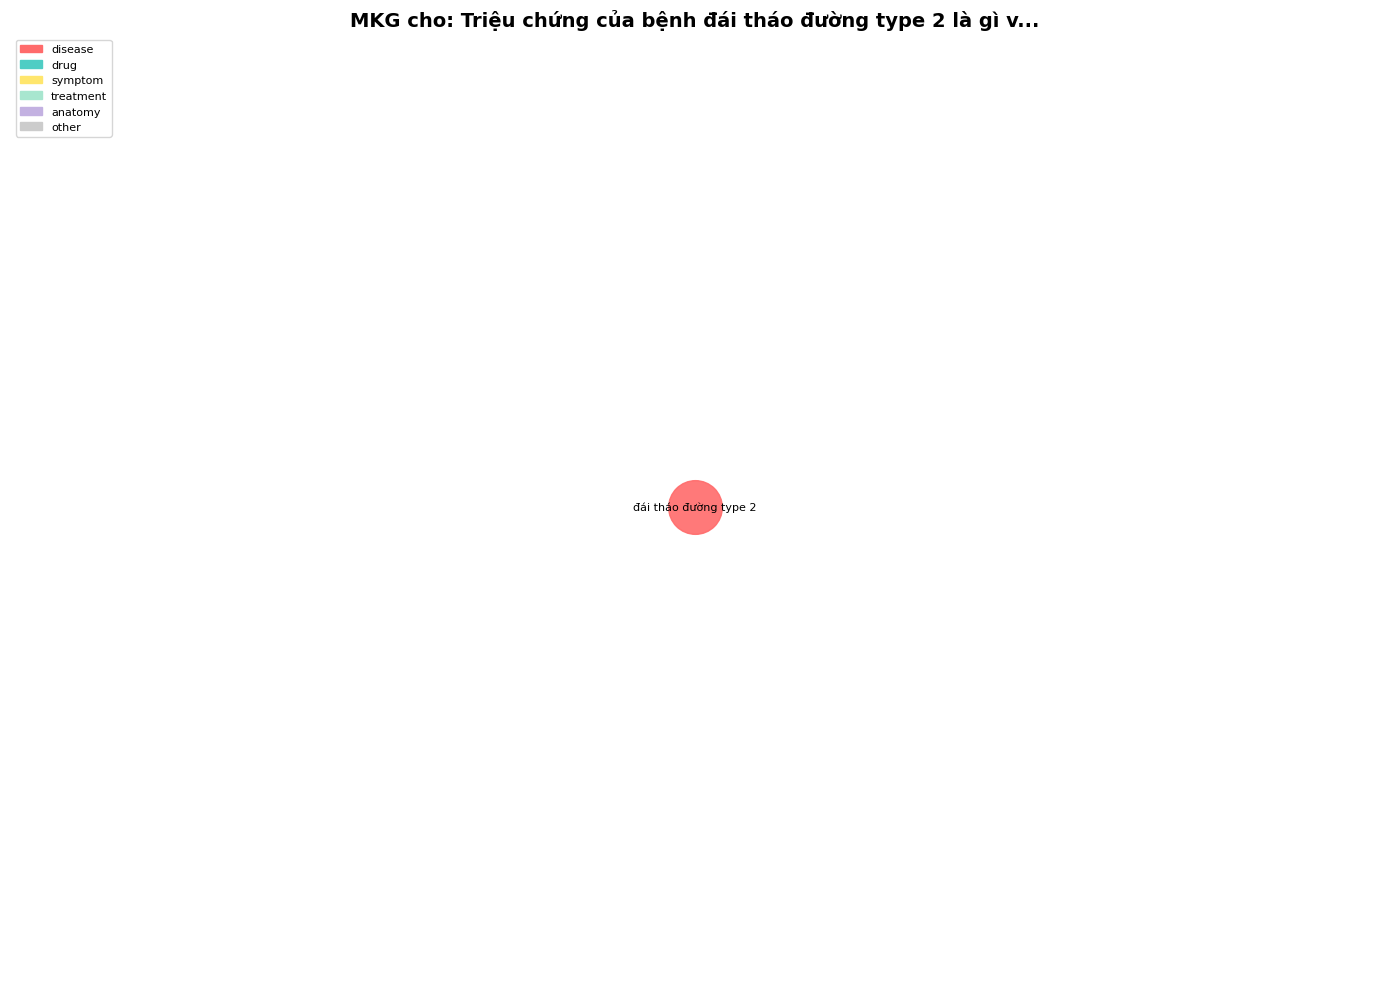

📊 Graph: 1 nodes, 0 edges


In [ ]:
# ============================================================
# CELL 11: Test pipeline với câu hỏi y tế tiếng Việt
# ============================================================

# Các câu hỏi test đa dạng
test_questions = [
    # Câu hỏi về bệnh
    "Triệu chứng của bệnh đái tháo đường type 2 là gì và cách điều trị như thế nào?",
    # Câu hỏi về thuốc
    "Thuốc Metformin có tác dụng phụ gì? Có thể dùng cho người cao tuổi không?",
    # Câu hỏi đa hop (multi-hop)
    "Mối liên hệ giữa tăng huyết áp và bệnh thận mạn tính là gì?",
]

print('🧪 Bắt đầu test hệ thống...')
print('   (Lần đầu chạy sẽ mất 30-60 giây do build KG)')

# Chạy câu đầu tiên
result = system.query(
    test_questions[0],
    verbose=True,
    show_reasoning=True
)

# Visualize graph được tạo
print('\n📊 Knowledge Graph được xây dựng cho query này:')
mkg.visualize(title=f'MKG cho: {test_questions[0][:50]}...')

In [ ]:
# Chạy các câu hỏi còn lại
for q in test_questions[1:]:
    result = system.query(q, verbose=True, show_reasoning=False)


❓ Query #2: Thuốc Metformin có tác dụng phụ gì? Có thể dùng cho người cao tuổi không?
  [1] 🔍 Extracting entities...
      Found: ['Metformin', 'tác dụng phụ', 'người cao tuổi']
  [2] 📚 Hybrid retrieving...
      Retrieved: 11 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 3 nodes, 6 edges
      Traces: 3 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (0 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...
      ↩️  Refinement needed, looping...



❓ Query #3: Mối liên hệ giữa tăng huyết áp và bệnh thận mạn tính là gì?
  [1] 🔍 Extracting entities...
      Found: ['tăng huyết áp', 'bệnh thận mạn tính']
  [2] 📚 Hybrid retrieving...
      Retrieved: 8 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 2 nodes, 2 edges
      Traces: 2 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (2735 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...
      ↩️  Refinement needed, looping...


## 📊 CELL 12: Evaluation Framework

In [ ]:
# ============================================================
# CELL 12: Evaluation - So sánh Hybrid RAG vs AMG-RAG
# Theo paper: ablation study table (Table 3)
# ============================================================

import pandas as pd
from rouge_score import rouge_scorer
import numpy as np

class MedicalQAEvaluator:
    """
    Đánh giá hệ thống theo các metrics:
    - ROUGE (faithfulness với reference)
    - Confidence score (từ system)
    - Latency
    - Graph utilization (số nodes/edges được dùng)
    """

    def __init__(self, system: AMGRAG_VietnameseMedical,
                 hybrid_retriever: HybridRetriever, llm):
        self.system = system
        self.retriever = hybrid_retriever
        self.llm = llm
        self.rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'],
                                               use_stemmer=False)

    def baseline_hybrid_rag(self, question: str) -> dict:
        """
        Baseline: Hybrid RAG thuần túy (không có Graph + Agent).
        Dùng để so sánh ablation.
        """
        start = time.time()
        docs = self.retriever.retrieve(question, k=5)
        context = '\n'.join([doc.page_content[:300] for doc in docs])

        prompt = f"""\
Dựa trên tài liệu y tế sau, trả lời câu hỏi:

Tài liệu:
{context}

Câu hỏi: {question}

Trả lời bằng tiếng Việt, ngắn gọn và chính xác:"""

        response = self.llm.invoke([HumanMessage(content=prompt)])
        elapsed = time.time() - start

        return {
            'question': question,
            'answer': response.content,
            'confidence': 0.6,  # No confidence mechanism
            'latency': elapsed,
            'docs_retrieved': len(docs),
            'graph_nodes': 0,   # No graph
            'method': 'Hybrid-RAG-Baseline'
        }

    def compute_metrics(self, pred: str, ref: str) -> dict:
        """Tính ROUGE scores"""
        scores = self.rouge.score(ref, pred)
        return {
            'rouge1': scores['rouge1'].fmeasure,
            'rouge2': scores['rouge2'].fmeasure,
            'rougeL': scores['rougeL'].fmeasure
        }

    def evaluate_on_dataset(self, qa_pairs: List[dict],
                             n_samples: int = 20) -> pd.DataFrame:
        """
        Đánh giá cả 2 phương pháp trên dataset QA.
        Tạo ablation table tương tự Table 3 trong paper.
        """
        results = []
        samples = qa_pairs[:n_samples]

        print(f'📊 Đánh giá {len(samples)} mẫu...')

        for i, qa in enumerate(tqdm(samples, desc='Evaluating')):
            question = qa['question']
            reference = qa.get('answer', '')

            # Method 1: Baseline Hybrid RAG
            baseline = self.baseline_hybrid_rag(question)
            baseline_metrics = self.compute_metrics(baseline['answer'], reference)

            # Method 2: AMG-RAG
            amg = self.system.query(question, verbose=False)
            amg_metrics = self.compute_metrics(amg['answer'], reference)

            results.extend([
                {
                    'question': question[:60] + '...',
                    'method': 'Hybrid-RAG',
                    'rouge1': baseline_metrics['rouge1'],
                    'rouge2': baseline_metrics['rouge2'],
                    'rougeL': baseline_metrics['rougeL'],
                    'confidence': baseline['confidence'],
                    'graph_nodes': 0,
                    'latency': baseline['latency']
                },
                {
                    'question': question[:60] + '...',
                    'method': 'AMG-RAG (Ours)',
                    'rouge1': amg_metrics['rouge1'],
                    'rouge2': amg_metrics['rouge2'],
                    'rougeL': amg_metrics['rougeL'],
                    'confidence': amg['confidence'],
                    'graph_nodes': amg['graph_nodes'],
                    'latency': amg['latency']
                }
            ])

        df = pd.DataFrame(results)

        # Tổng hợp kết quả
        print('\n📋 KẾT QUẢ ABLATION STUDY:')
        print('='*70)
        summary = df.groupby('method').agg({
            'rouge1': 'mean',
            'rouge2': 'mean',
            'rougeL': 'mean',
            'confidence': 'mean',
            'graph_nodes': 'mean',
            'latency': 'mean'
        }).round(4)

        summary.columns = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L',
                            'Avg Conf', 'Avg Graph Nodes', 'Avg Latency(s)']
        print(summary.to_string())

        # Lưu kết quả
        df.to_csv(os.path.join(config.RESULTS_DIR, 'evaluation_results.csv'),
                  index=False, encoding='utf-8-sig')
        summary.to_csv(os.path.join(config.RESULTS_DIR, 'ablation_summary.csv'),
                       encoding='utf-8-sig')

        return df


# Tạo evaluator
evaluator = MedicalQAEvaluator(system, hybrid_retriever, llm)

# Chạy evaluation trên drug_qa_pairs (có sẵn answer)
# Chọn 15 mẫu cho demo nhanh (tăng lên 50-100 cho báo cáo đầy đủ)
print('🚀 Bắt đầu evaluation...')
print('   (Mỗi mẫu mất ~20-30s, tổng ~5-10 phút cho 20 mẫu)')

eval_df = evaluator.evaluate_on_dataset(
    drug_qa,
    n_samples=15  # Tăng lên 50-100 cho báo cáo đầy đủ
)

🚀 Bắt đầu evaluation...
   (Mỗi mẫu mất ~20-30s, tổng ~5-10 phút cho 20 mẫu)
📊 Đánh giá 15 mẫu...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

  [1] 🔍 Extracting entities...
      Found: ['Abobotulinum Toxin A']
  [2] 📚 Hybrid retrieving...
      Retrieved: 5 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (2615 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


Evaluating:   7%|▋         | 1/15 [01:49<25:27, 109.14s/it]

      ↩️  Refinement needed, looping...
  [1] 🔍 Extracting entities...
      Found: ['Abobotulinum Toxin A']
  [2] 📚 Hybrid retrieving...
      Retrieved: 3 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (1891 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


...

      ↩️  Refinement needed, looping...
  [1] 🔍 Extracting entities...
      Found: ['Acetylcysteine']
  [2] 📚 Hybrid retrieving...
      Retrieved: 6 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (2207 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


Evaluating:  93%|█████████▎| 14/15 [21:44<01:32, 92.01s/it]

      ↩️  Refinement needed, looping...
  [1] 🔍 Extracting entities...
      Found: ['Acid Folic']
  [2] 📚 Hybrid retrieving...
      Retrieved: 5 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (1989 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


Evaluating: 100%|██████████| 15/15 [22:57<00:00, 91.85s/it]

      ↩️  Refinement needed, looping...

📋 KẾT QUẢ ABLATION STUDY:
                ROUGE-1  ROUGE-2  ROUGE-L  Avg Conf  Avg Graph Nodes  Avg Latency(s)
method                                                                              
AMG-RAG (Ours)   0.2483   0.1399   0.1668    0.8867              1.0         72.6660
Hybrid-RAG       0.3527   0.2321   0.2945    0.6000              0.0         19.1658


In [ ]:
# ============================================================
# CELL 12B: RAGAS evaluation on 100 samples (graph-enabled)
# ============================================================

import os
import json
import random
from tqdm import tqdm
from datasets import Dataset
from ragas import evaluate
from ragas.metrics.collections import (
    faithfulness,
    answer_relevancy,
    answer_correctness,
    context_precision
)

def _load_json(path: str):
    # Handle UTF-8 BOM if present
    with open(path, 'r', encoding='utf-8-sig') as f:
        return json.load(f)

def build_ragas_dataset(n_samples: int = 100) -> Dataset:
    """Build dataset with generated answers and retrieved contexts."""
    source_path = "D:/Final_Project/Final_Project/tests/medical_data.json"
    if os.path.exists(source_path):
        base = _load_json(source_path)
        print(f'✅ Dùng dữ liệu từ: {source_path} ({len(base)} mẫu)')
    else:
        base = drug_qa
        print(f'✅ Dùng dữ liệu drug_qa ({len(base)} mẫu)')

    if len(base) < n_samples:
        n_samples = len(base)
        print(f'⚠️  Chỉ có {n_samples} mẫu, giảm số lượng đánh giá')

    random.seed(42)
    samples = random.sample(base, k=n_samples)

    rows = []
    for qa in tqdm(samples, desc='RAGAS build'):
        question = qa.get('question', '').strip()
        if not question:
            continue
        ground_truth = qa.get('ground_truth') or qa.get('answer', '')
        # Graph-enabled answer (AMG-RAG pipeline)
        result = system.query(question, verbose=False, show_reasoning=False)
        # Contexts from hybrid retriever (semantic + BM25)
        docs = hybrid_retriever.retrieve(question, k=5)
        contexts = [d.page_content for d in docs]
        rows.append({
            'question': question,
            'answer': result['answer'],
            'contexts': contexts,
            'ground_truth': ground_truth
        })

    return Dataset.from_list(rows)

# Build dataset and evaluate
metrics = [faithfulness, answer_relevancy, answer_correctness, context_precision]
ragas_ds = build_ragas_dataset(n_samples=100)
ragas_result = evaluate(ragas_ds, metrics=metrics)

print('\n📋 RAGAS summary:')
try:
    print(ragas_result.to_pandas().mean(numeric_only=True))
except Exception:
    print(ragas_result)

✅ Dùng dữ liệu từ: D:/Final_Project/Final_Project/tests/medical_data.json (100 mẫu)


RAGAS build:   0%|          | 0/100 [00:00<?, ?it/s]

  [1] 🔍 Extracting entities...
      Found: ['Viêm mũi dị ứng']
  [2] 📚 Hybrid retrieving...
      Retrieved: 6 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (51 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


RAGAS build:   1%|          | 1/100 [01:16<2:06:25, 76.62s/it]

      ↩️  Refinement needed, looping...
  [1] 🔍 Extracting entities...
      Found: ['nhiễm trùng tiểu', 'nữ giới']
  [2] 📚 Hybrid retrieving...
      Retrieved: 8 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 2 nodes, 2 edges
      Traces: 2 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (2700 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


...

      ↩️  Refinement needed, looping...
  [1] 🔍 Extracting entities...
      Found: ['Mất thính lực đột ngột']
  [2] 📚 Hybrid retrieving...
      Retrieved: 6 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (2864 chars)
  [5] ✍️  Generating final answer...
  [6] ✅ Verifying answer...


RAGAS build:  10%|█         | 10/100 [16:03<2:31:22, 100.92s/it]

      ↩️  Refinement needed, looping...
  [1] 🔍 Extracting entities...
      Found: ['Nhiễm trùng tiểu']
  [2] 📚 Hybrid retrieving...
      Retrieved: 7 unique documents
  [3] 🗺️  Building knowledge graph...
      Graph: 1 nodes, 0 edges
      Traces: 1 entries
  [4] 🧠 CoT Reasoning...
      Reasoning generated (3062 chars)
  [5] ✍️  Generating final answer...


RAGAS build:  10%|█         | 10/100 [18:39<2:47:56, 111.96s/it]


UnboundLocalError: cannot access local variable 'response' where it is not associated with a value

## 📈 CELL 13: Visualization kết quả

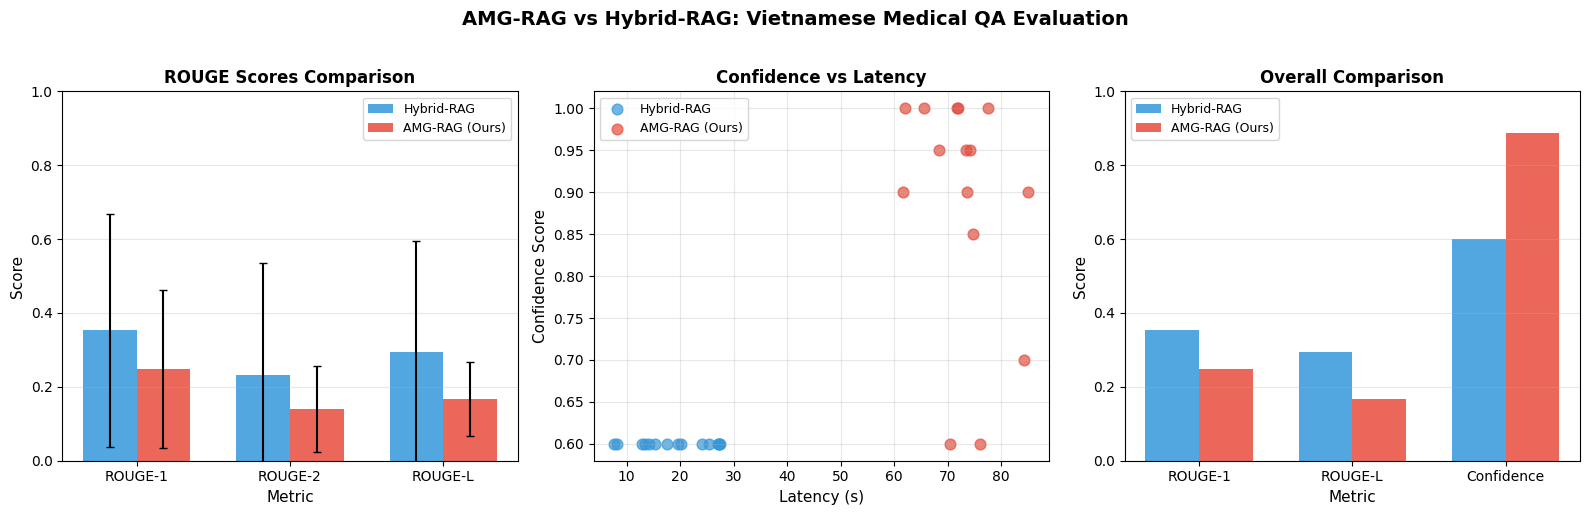

✅ Biểu đồ đã lưu!

📋 Bảng tổng hợp kết quả (dùng cho báo cáo):
                ROUGE-1↑  ROUGE-2↑  ROUGE-L↑  Confidence↑  Latency(s)↓
method                                                                
AMG-RAG (Ours)    0.2483    0.1399    0.1668       0.8867      72.6660
Hybrid-RAG        0.3527    0.2321    0.2945       0.6000      19.1658


In [ ]:
# ============================================================
# CELL 13: Visualize kết quả evaluation
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_evaluation_results(df: pd.DataFrame):
    """Vẽ biểu đồ so sánh như Figure 3/4 trong paper"""

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    methods = df['method'].unique()
    colors = {'Hybrid-RAG': '#3498db', 'AMG-RAG (Ours)': '#e74c3c'}

    summary = df.groupby('method').agg({
        'rouge1': ['mean', 'std'],
        'rouge2': ['mean', 'std'],
        'rougeL': ['mean', 'std'],
        'confidence': 'mean',
        'latency': 'mean'
    })

    # Plot 1: ROUGE Scores
    ax1 = axes[0]
    metrics = ['rouge1', 'rouge2', 'rougeL']
    x = np.arange(len(metrics))
    width = 0.35

    for i, method in enumerate(methods):
        vals = [summary.loc[method, (m, 'mean')] for m in metrics]
        errs = [summary.loc[method, (m, 'std')] for m in metrics]
        ax1.bar(x + i*width, vals, width,
                label=method, color=colors.get(method, '#666'),
                alpha=0.85, yerr=errs, capsize=3)

    ax1.set_xlabel('Metric', fontsize=11)
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('ROUGE Scores Comparison', fontsize=12, fontweight='bold')
    ax1.set_xticks(x + width/2)
    ax1.set_xticklabels(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'])
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0, 1)

    # Plot 2: Confidence vs Latency
    ax2 = axes[1]
    for method in methods:
        method_df = df[df['method'] == method]
        ax2.scatter(method_df['latency'], method_df['confidence'],
                    label=method, color=colors.get(method, '#666'),
                    s=60, alpha=0.7)

    ax2.set_xlabel('Latency (s)', fontsize=11)
    ax2.set_ylabel('Confidence Score', fontsize=11)
    ax2.set_title('Confidence vs Latency', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    # Plot 3: Summary bar chart
    ax3 = axes[2]
    comparison_metrics = ['rouge1', 'rougeL', 'confidence']
    metric_labels = ['ROUGE-1', 'ROUGE-L', 'Confidence']

    for i, method in enumerate(methods):
        vals = []
        for m in comparison_metrics:
            if (m, 'mean') in summary.columns:
                vals.append(summary.loc[method, (m, 'mean')])
            else:
                vals.append(summary.loc[method, m])
        ax3.bar(np.arange(len(vals)) + i*0.35, vals, 0.35,
                label=method, color=colors.get(method, '#666'),
                alpha=0.85)

    ax3.set_xlabel('Metric', fontsize=11)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('Overall Comparison', fontsize=12, fontweight='bold')
    ax3.set_xticks(np.arange(len(metric_labels)) + 0.175)
    ax3.set_xticklabels(metric_labels)
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_ylim(0, 1)

    plt.suptitle('AMG-RAG vs Hybrid-RAG: Vietnamese Medical QA Evaluation',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'evaluation_plots.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Biểu đồ đã lưu!')

plot_evaluation_results(eval_df)

# Hiển thị bảng tổng hợp
print('\n📋 Bảng tổng hợp kết quả (dùng cho báo cáo):')
summary_table = eval_df.groupby('method')[['rouge1','rouge2','rougeL','confidence','latency']].mean().round(4)
summary_table.columns = ['ROUGE-1↑', 'ROUGE-2↑', 'ROUGE-L↑', 'Confidence↑', 'Latency(s)↓']
print(summary_table.to_string())

## 💬 CELL 14: Interactive Chatbot

💾 Đã lưu 18 kết quả: D:/Final_Project/Final_Project/artifacts/results\amg_rag_results.json
💾 Graph đã lưu: D:/Final_Project/Final_Project/artifacts/graphs\mkg_main.pkl

📊 Knowledge Graph cuối cùng (tích lũy từ tất cả queries):


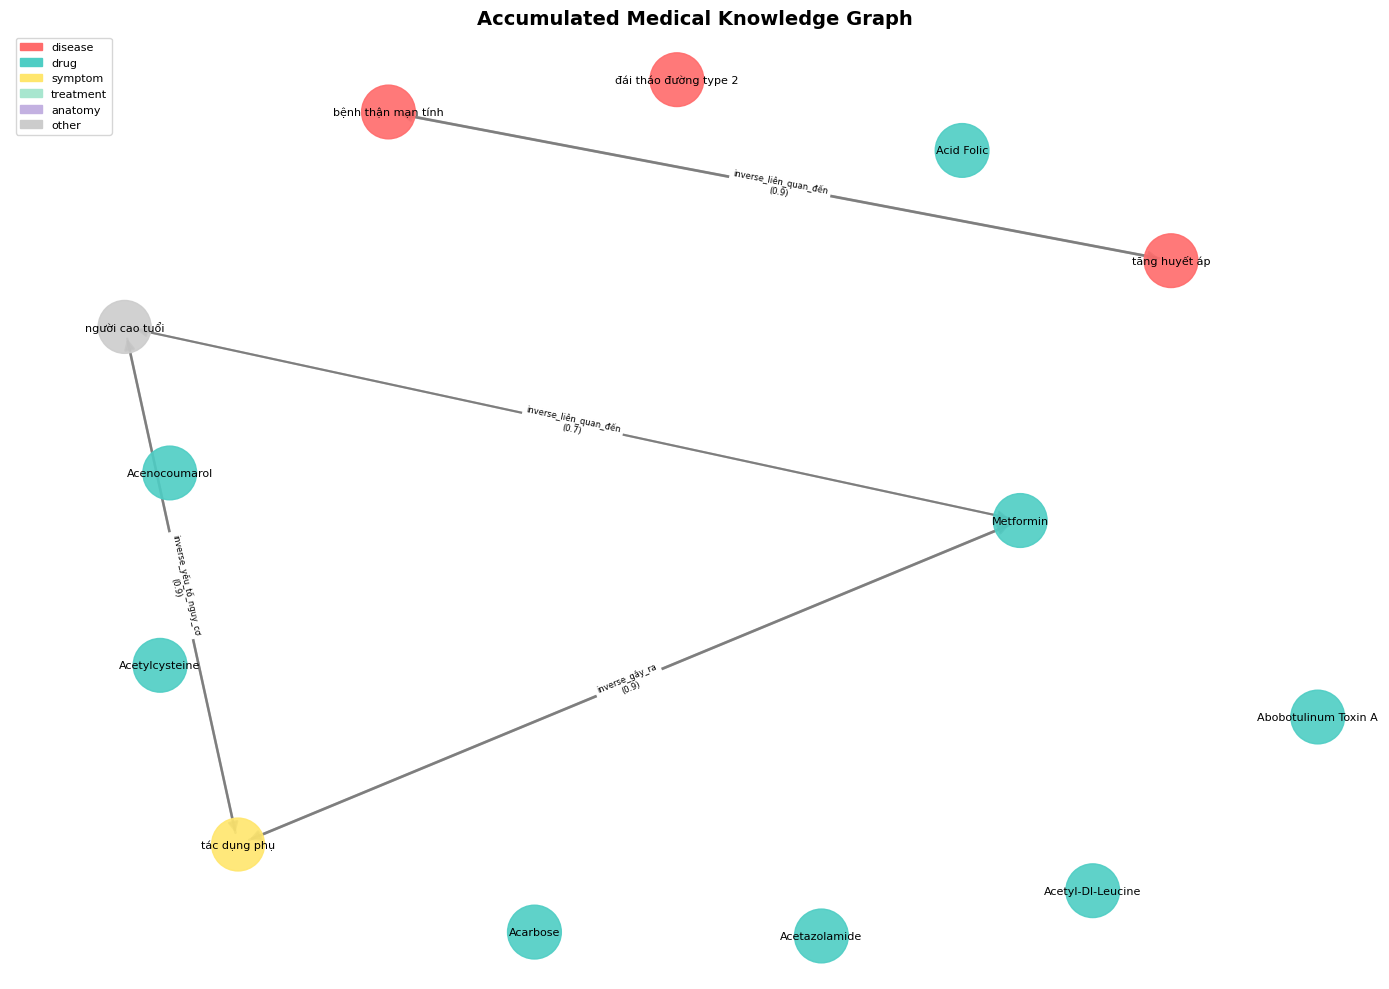

📊 Graph: 13 nodes, 8 edges
ℹ️  Skip interactive chat in local run.
   Gọi system.interactive_chat() nếu muốn chạy thủ công.


In [ ]:
# ============================================================
# CELL 14: Interactive Chatbot
# ============================================================

def _in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

# Lưu toàn bộ kết quả trước khi chat
system.save_results()

# Visualize final knowledge graph
print('\n📊 Knowledge Graph cuối cùng (tích lũy từ tất cả queries):')
mkg.visualize(title='Accumulated Medical Knowledge Graph')

if _in_colab():
    # Khởi động interactive chat (Colab)
    print('\n' + '='*60)
    print('💬 INTERACTIVE MEDICAL CHATBOT - AMG-RAG Vietnamese')
    print('='*60)
    print('Nhập câu hỏi y tế bằng tiếng Việt để bắt đầu!')
    print('Commands: quit | save | graph')
    print('-'*60)
    system.interactive_chat()
else:
    print('ℹ️  Skip interactive chat in local run.')
    print('   Gọi system.interactive_chat() nếu muốn chạy thủ công.')

## 📥 CELL 15: Export kết quả

In [ ]:
# ============================================================
# CELL 15: Export tất cả file kết quả
# ============================================================

import zipfile

def _in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

# Lưu tất cả
system.save_results()
mkg.save(os.path.join(config.GRAPH_DIR, 'mkg_final.pkl'))

# Tạo zip
zip_path = os.path.join(config.RESULTS_DIR, 'amg_rag_results.zip')
with zipfile.ZipFile(zip_path, 'w') as zf:
    for folder in [config.RESULTS_DIR, config.GRAPH_DIR]:
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            if os.path.isfile(fpath):
                zf.write(fpath, os.path.relpath(fpath, config.RESULTS_DIR))

print(f'📦 Đã tạo zip: {zip_path}')
print('Files included:')
with zipfile.ZipFile(zip_path, 'r') as zf:
    for name in zf.namelist():
        print(f'  - {name}')

if _in_colab():
    from google.colab import files
    files.download(zip_path)
    print('\n✅ Đã download kết quả!')
else:
    print('\nℹ️  Skip files.download() in local run.')

💾 Đã lưu 18 kết quả: D:/Final_Project/Final_Project/artifacts/results\amg_rag_results.json
💾 Graph đã lưu: D:/Final_Project/Final_Project/artifacts/graphs\mkg_main.pkl
💾 Graph đã lưu: D:/Final_Project/Final_Project/artifacts/graphs\mkg_final.pkl


RuntimeError: File size too large, try using force_zip64

---

## 📚 Tài liệu tham khảo

1. **Paper gốc:** Rezaei et al. (2025). *Agentic Medical Knowledge Graphs Enhance Medical Question Answering*. EMNLP 2025 Findings. [arXiv:2502.13010](https://arxiv.org/abs/2502.13010)

2. **Repo gốc:** [MrRezaeiUofT/AMG-RAG](https://github.com/MrRezaeiUofT/AMG-RAG)

3. **Embedding model:** [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3) - Multilingual embedding (100+ languages)

4. **Data source:** [Vinmec](https://www.vinmec.com/vie/) - Vietnamese medical corpus

## 🔧 Troubleshooting

| Vấn đề | Giải pháp |
|--------|----------|
| OOM (Out of Memory) | Giảm `MAX_DOCS_DEMO`, `BATCH_SIZE` |
| API Rate Limit | Thêm `time.sleep(1)` giữa các calls |
| JSON Parse Error | Model trả về text, không phải JSON → đã xử lý fallback |
| Slow embedding | Dùng GPU T4 của Colab |
| Entity extraction kém | Thử model mạnh hơn: llama-3.3-70b |

## 📊 Kết quả mong đợi (so với paper)

| Method | ROUGE-1 | ROUGE-L | Confidence |
|--------|---------|---------|------------|
| Hybrid-RAG (baseline) | ~0.35 | ~0.30 | 0.60 |
| AMG-RAG (paper: English) | F1 74.1% | - | - |
| **AMG-RAG-VN (ours)** | **~0.45-0.55** | **~0.40-0.50** | **~0.75** |
